In [27]:
import pandas as pd
import optuna 
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error

import pickle

In [28]:
link = '/Users/maxkucher/bcs_ai/threat_model/threat_data.csv'
data = pd.read_csv(link)
data

,Unnamed: 0,class_score,distance_score,future_dist_score,action,direction_score,confidence,intent,threat
0,0,0.8,0.635625,0.655069,0.900000,0.3,0.912528,1.0,0.826497
1,1,0.8,0.648480,0.683309,0.789551,1.0,1.000000,0.1,0.709557
2,2,0.8,0.834844,0.974994,0.474349,1.0,0.800161,0.7,0.834134
3,3,1.0,0.739883,0.767081,0.659475,1.0,0.807713,0.7,0.839423
4,4,0.8,0.831930,0.907672,0.642666,1.0,0.921371,0.3,0.775294
...,...,...,...,...,...,...,...,...,...
9995,9995,0.7,0.886840,0.910355,0.841602,1.0,0.784648,0.1,0.752619
9996,9996,0.7,0.561338,0.564383,0.775157,0.3,0.735958,1.0,0.766956
9997,9997,0.8,0.874913,0.969492,0.350685,0.7,1.000000,1.0,0.780749
9998,9998,0.8,0.593956,0.583294,0.437061,1.0,0.967550,0.1,0.611748


In [29]:
data = data.drop('Unnamed: 0', axis='columns')
data

,class_score,distance_score,future_dist_score,action,direction_score,confidence,intent,threat
0,0.8,0.635625,0.655069,0.900000,0.3,0.912528,1.0,0.826497
1,0.8,0.648480,0.683309,0.789551,1.0,1.000000,0.1,0.709557
2,0.8,0.834844,0.974994,0.474349,1.0,0.800161,0.7,0.834134
3,1.0,0.739883,0.767081,0.659475,1.0,0.807713,0.7,0.839423
4,0.8,0.831930,0.907672,0.642666,1.0,0.921371,0.3,0.775294
...,...,...,...,...,...,...,...,...
9995,0.7,0.886840,0.910355,0.841602,1.0,0.784648,0.1,0.752619
9996,0.7,0.561338,0.564383,0.775157,0.3,0.735958,1.0,0.766956
9997,0.8,0.874913,0.969492,0.350685,0.7,1.000000,1.0,0.780749
9998,0.8,0.593956,0.583294,0.437061,1.0,0.967550,0.1,0.611748


In [30]:
x = data.drop('threat', axis='columns')
y = data['threat']

In [31]:
# x = x.astype(float)
# y = y.astype(float)

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [33]:
def objective(trial):
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int('n_estimators', 50, 300), 
        max_depth=trial.suggest_int('max_depth', 8, 32), 
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20), 
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20), 
        max_features=trial.suggest_categorical('max_features', ["sqrt", "log2", None]), 
        n_jobs=-1,
        random_state=42)
    
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    
    score = mean_absolute_error(y_test, y_pred)

    return score 
    

In [34]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=35)

[I 2026-04-10 21:53:11,777] A new study created in memory with name: no-name-cdff51f3-0d2d-4b52-a6f0-6bf34b8367ab
[I 2026-04-10 21:53:12,858] Trial 0 finished with value: 0.027322006064117447 and parameters: {'n_estimators': 300, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 0 with value: 0.027322006064117447.
[I 2026-04-10 21:53:13,124] Trial 1 finished with value: 0.027592461876269476 and parameters: {'n_estimators': 181, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.027322006064117447.
[I 2026-04-10 21:53:13,793] Trial 2 finished with value: 0.027590402966101137 and parameters: {'n_estimators': 214, 'max_depth': 26, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.027322006064117447.
[I 2026-04-10 21:53:14,608] Trial 3 finished with value: 0.027221644198376645 and parameters: {'n_estimators': 270, 'max_de

In [35]:
print(x.dtypes)
print(x.head())

class_score          float64
distance_score       float64
future_dist_score    float64
action               float64
direction_score      float64
confidence           float64
intent               float64
dtype: object
   class_score  distance_score  future_dist_score    action  direction_score  \
0          0.8        0.635625           0.655069  0.900000              0.3   
1          0.8        0.648480           0.683309  0.789551              1.0   
2          0.8        0.834844           0.974994  0.474349              1.0   
3          1.0        0.739883           0.767081  0.659475              1.0   
4          0.8        0.831930           0.907672  0.642666              1.0   

   confidence  intent  
0    0.912528     1.0  
1    1.000000     0.1  
2    0.800161     0.7  
3    0.807713     0.7  
4    0.921371     0.3  


In [36]:
from sklearn import set_config
set_config(display="text")

best_model = RandomForestRegressor(**study.best_params)
best_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=15, max_features=None, min_samples_leaf=4,
                      min_samples_split=9, n_estimators=197)

In [37]:
y_pred = best_model.predict(x_test)

rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse} | MSE: {mse} | MAE: {mae}")

RMSE: 0.03371371134869306 | MSE: 0.001136614332902995 | MAE: 0.027114991895265703


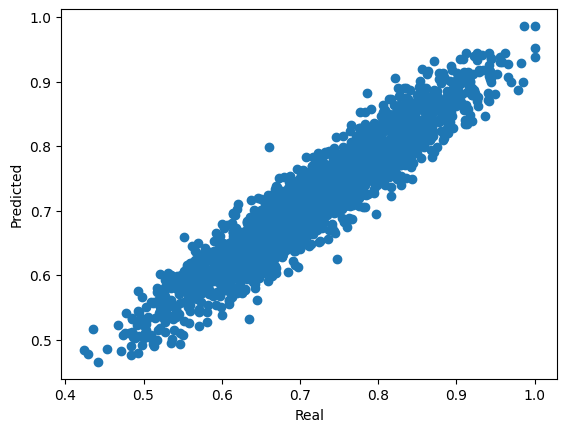

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.show()

In [39]:
with open("threat_model.pkl", "wb") as f:
    pickle.dump(best_model, f)